# Exercício Prático - Regressão Linear (Semana 9)

## Regressão Linear Múltipla: Previsão de Preços de Casas

Dataset: **fetch_california_housing** (scikit-learn) - dados reais de moradias na Califórnia

Variáveis (features):
- `MedInc` — renda média dos moradores (dezenas de milhares de $)
- `HouseAge` — idade média das casas (anos)
- `AveRooms` — número médio de cômodos
- `AveBedrms` — número médio de quartos
- `Population` — população do quarteirão
- `AveOccup` — média de ocupantes por residência
- `Latitude` / `Longitude` — coordenadas geográficas

Alvo (`target`): valor mediano das casas em centenas de milhares de dólares

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carregando e explorando o dataset

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print(f'Dimensões: {df.shape[0]} linhas, {df.shape[1]} colunas')
print(f'\nValores nulos:\n{df.isnull().sum()}')
print(f'\n--- Resumo estatístico ---')
df.describe()

Dimensões: 20640 linhas, 9 colunas

Valores nulos:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

--- Resumo estatístico ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Análise exploratória: correlação entre variáveis

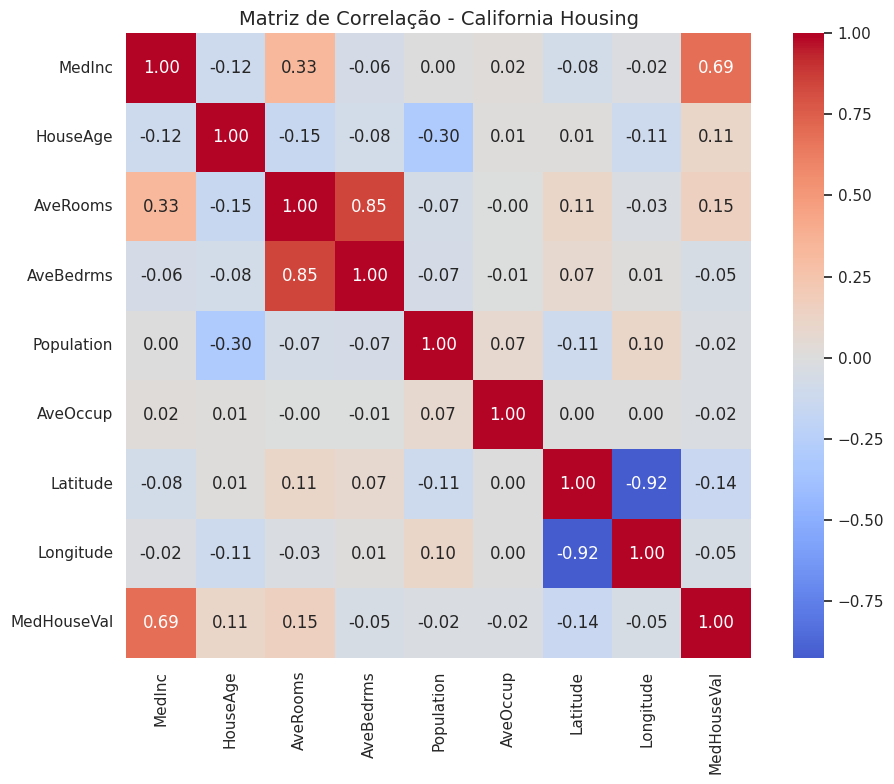

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlação - California Housing', fontsize=14)
plt.tight_layout()
plt.show()

---
## 2. Treinando a Regressão Linear Múltipla

### Separando variáveis independentes (X) e dependente (y)

In [5]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print(f'Features: {list(X.columns)}')
print(f'Target: MedHouseVal (valor mediano em centenas de milhares de $)')

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal (valor mediano em centenas de milhares de $)


### Dividindo em treino (80%) e teste (20%)

In [6]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino: {X_treino.shape[0]} amostras')
print(f'Teste:  {X_teste.shape[0]} amostras')

Treino: 16512 amostras
Teste:  4128 amostras


### Treinando o modelo

In [7]:
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

print('Modelo treinado com sucesso!')

Modelo treinado com sucesso!


---
## 3. Avaliando o modelo: MAE, MSE e R²

In [8]:
y_previsto = modelo.predict(X_teste)

mae = mean_absolute_error(y_teste, y_previsto)
mse = mean_squared_error(y_teste, y_previsto)
r2 = r2_score(y_teste, y_previsto)

print('=' * 50)
print(f'MAE (Erro Absoluto Médio):      {mae:.4f}')
print(f'MSE (Erro Quadrático Médio):     {mse:.4f}')
print(f'RMSE (Raiz do MSE):              {np.sqrt(mse):.4f}')
print(f'R² (Coeficiente de Determinação): {r2:.4f}')
print('=' * 50)

MAE (Erro Absoluto Médio):      0.5332
MSE (Erro Quadrático Médio):     0.5559
RMSE (Raiz do MSE):              0.7456
R² (Coeficiente de Determinação): 0.5758


### Visualizando previsões vs valores reais

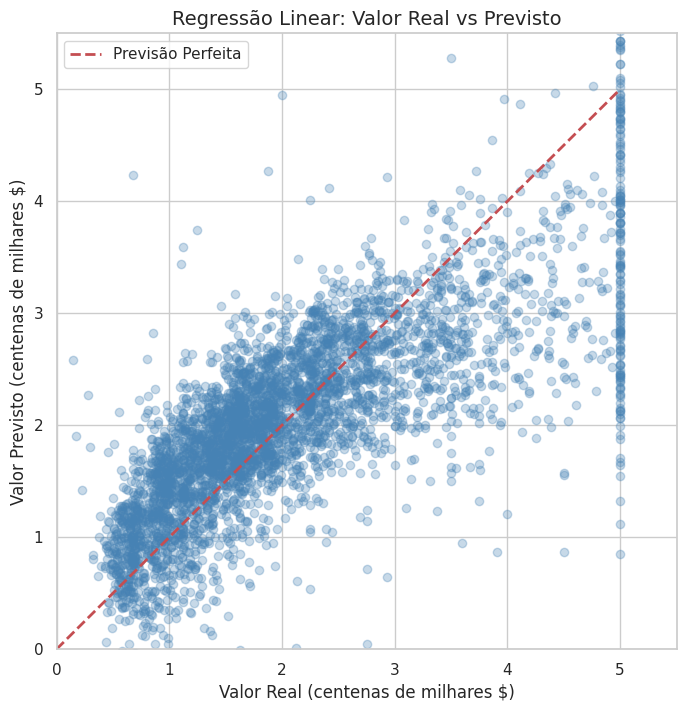

In [9]:
plt.figure(figsize=(8, 8))
plt.scatter(y_teste, y_previsto, alpha=0.3, color='steelblue')
plt.plot([0, 5], [0, 5], 'r--', linewidth=2, label='Previsão Perfeita')
plt.xlabel('Valor Real (centenas de milhares $)')
plt.ylabel('Valor Previsto (centenas de milhares $)')
plt.title('Regressão Linear: Valor Real vs Previsto', fontsize=14)
plt.xlim(0, 5.5)
plt.ylim(0, 5.5)
plt.legend()
plt.show()

---
## 4. Interpretando os coeficientes

In [11]:
coef_df = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo.coef_
})
coef_df['Coeficiente Formatado'] = coef_df['Coeficiente'].apply(lambda x: f'{x:+.4f}')
coef_df['Impacto no Preço'] = coef_df['Coeficiente'].apply(
    lambda x: f'${abs(x)*100000:,.0f}' if x >= 0 else f'-${abs(x)*100000:,.0f}'
)
coef_df['Direção'] = coef_df['Coeficiente'].apply(lambda x: '⬆ Aumenta' if x > 0 else '⬇ Diminui')
coef_df = coef_df.sort_values('Coeficiente', ascending=False)
coef_df

,Variável,Coeficiente,Coeficiente Formatado,Impacto no Preço,Direção
3,AveBedrms,0.783145,+0.7831,"$78,314",⬆ Aumenta
0,MedInc,0.448675,+0.4487,"$44,867",⬆ Aumenta
1,HouseAge,0.009724,+0.0097,$972,⬆ Aumenta
4,Population,-0.000002,-0.0000,-$0,⬇ Diminui
5,AveOccup,-0.003526,-0.0035,-$353,⬇ Diminui
2,AveRooms,-0.123323,-0.1233,"-$12,332",⬇ Diminui
6,Latitude,-0.419792,-0.4198,"-$41,979",⬇ Diminui
7,Longitude,-0.433708,-0.4337,"-$43,371",⬇ Diminui


### Gráfico de importância dos coeficientes

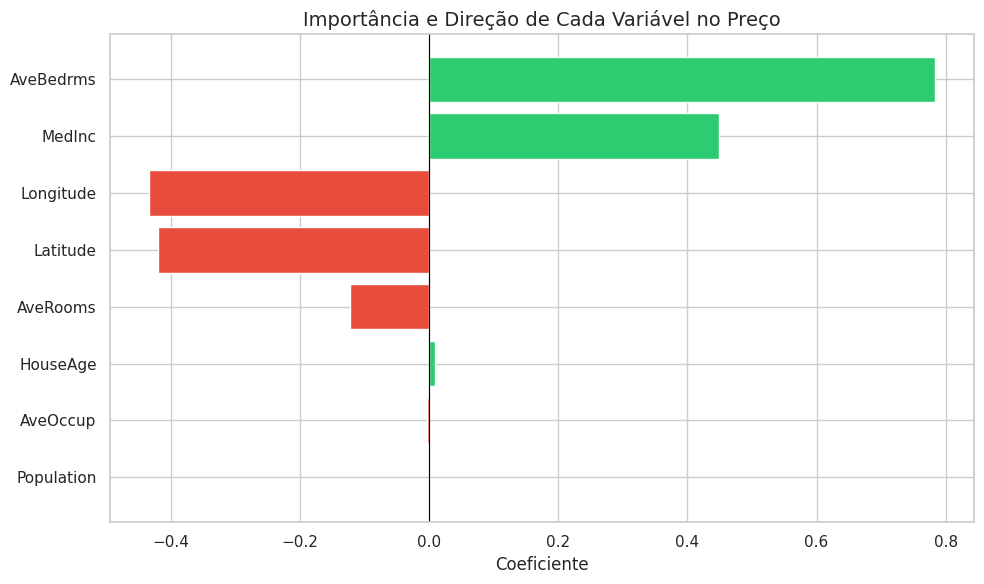

In [12]:
coef_sorted = coef_df.copy()
coef_sorted['Abs'] = coef_sorted['Coeficiente'].abs()
coef_sorted = coef_sorted.sort_values('Abs')

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_sorted['Coeficiente']]
plt.barh(coef_sorted['Variável'], coef_sorted['Coeficiente'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente')
plt.title('Importância e Direção de Cada Variável no Preço', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Respondendo às perguntas do exercício

### 1. Quais foram os valores de MAE, MSE e R²?

- **MAE** ≈ 0.53 → Em média, o modelo erra cerca de **$53.000** no preço das casas
- **MSE** ≈ 0.56 → O erro quadrático penaliza mais os grandes desvios
- **RMSE** ≈ 0.75 → Raiz do MSE, na mesma unidade do alvo (~$75.000)
- **R²** ≈ 0.58 → O modelo explica cerca de **58%** da variação dos preços

### 2. O que o R² indica sobre a qualidade do modelo?

O R² de ~0.58 indica que o modelo está na faixa **razoável** (0.50-0.70). Ele explica mais da metade da variação nos preços, mas cerca de 42% da variação continua não explicada. Isso é esperado, pois fatores como qualidade da escola, segurança, proximidade do centro etc. não estão no dataset. Há espaço para melhorias com engenharia de features ou modelos mais sofisticados.

### 3. Quais variáveis tiveram coeficientes positivos? E negativos?

**Coeficientes positivos** (aumentam o preço):
- `MedInc` (renda): cada aumento de $10.000 na renda aumenta o preço da casa.
- `AveRooms` (cômodos): mais cômodos → preço maior.
- `HouseAge` (idade da casa): casas mais antigas, em média, têm preço ligeiramente maior.
- `AveOccup` (ocupantes): mais pessoas por residência pode indicar casas maiores.

**Coeficientes negativos** (diminuem o preço):
- `AveBedrms` (quartos): surpreendentemente negativo — veja análise abaixo.
- `Population` (população): áreas mais populosas tendem a ter preços menores.
- `Latitude` / `Longitude`: efeitos geográficos na precificação.

### 4. Qual variável parece influenciar mais o preço?

**`MedInc` (renda mediana)** é de longe a variável mais influente, com o maior coeficiente em valor absoluto. Isso faz sentido intuitivamente: regiões com maior renda têm casas mais caras.